In [ ]:
# RUthvik Patil
# DL lab assignment 2
# Regression 
# 21/01/25
# House price prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load your dataset
df = pd.read_csv("/home/ruthvik/Downloads/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Convert binary categorical variables to 0/1
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'yes':1, 'no':0}))

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

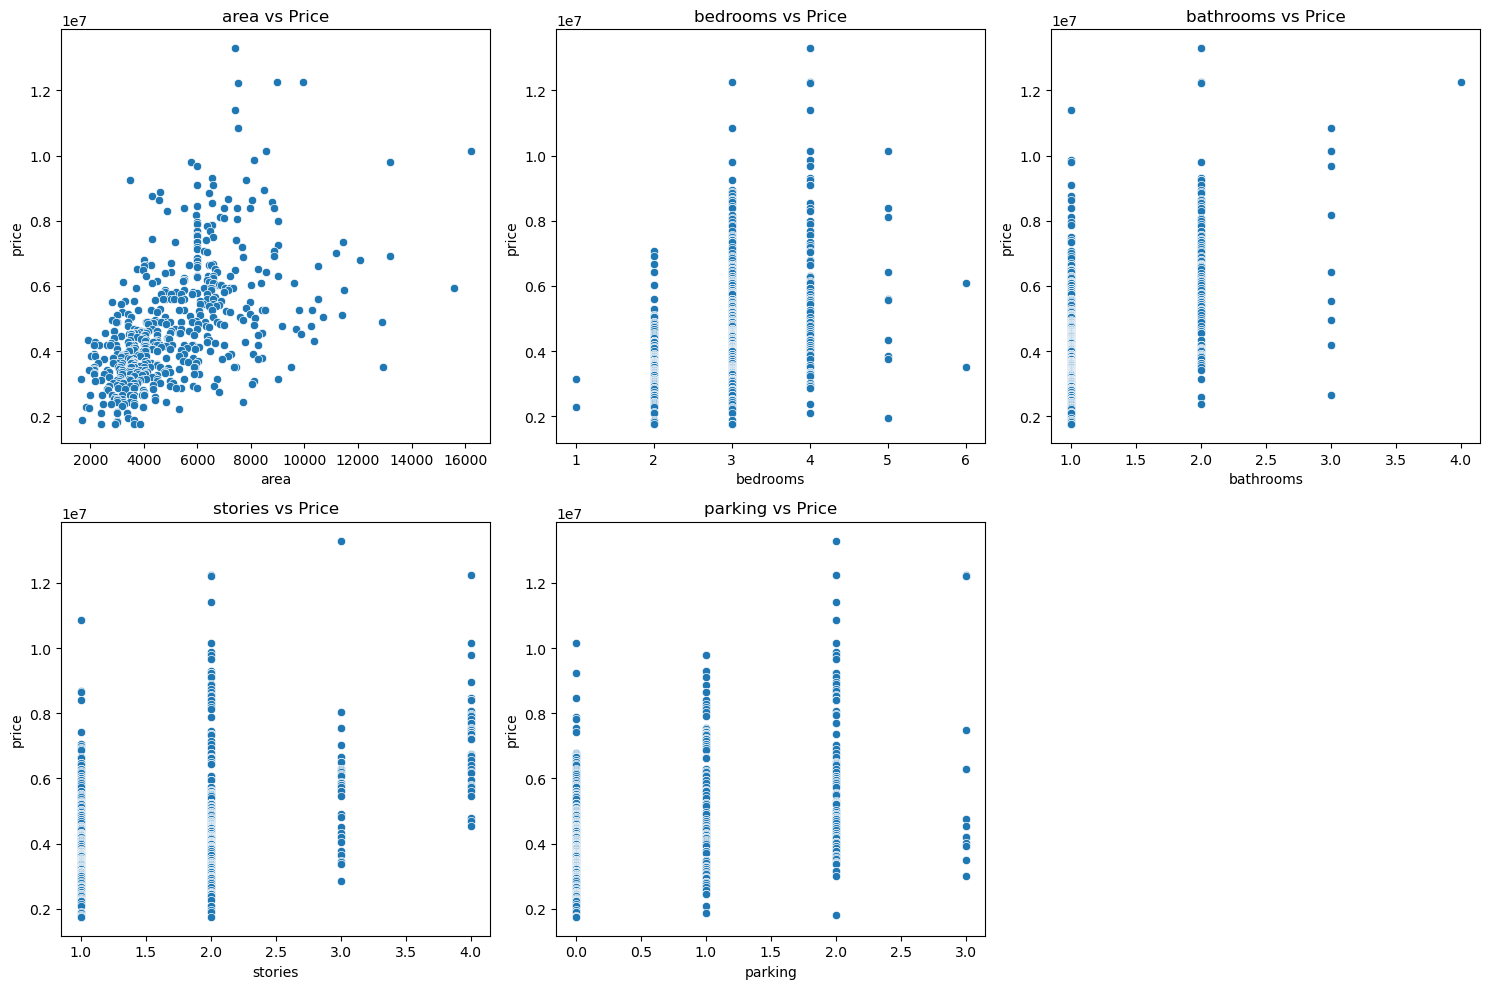

In [6]:
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
plt.figure(figsize=(15,10))
for i, col in enumerate(num_features):
    plt.subplot(2,3,i+1)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()

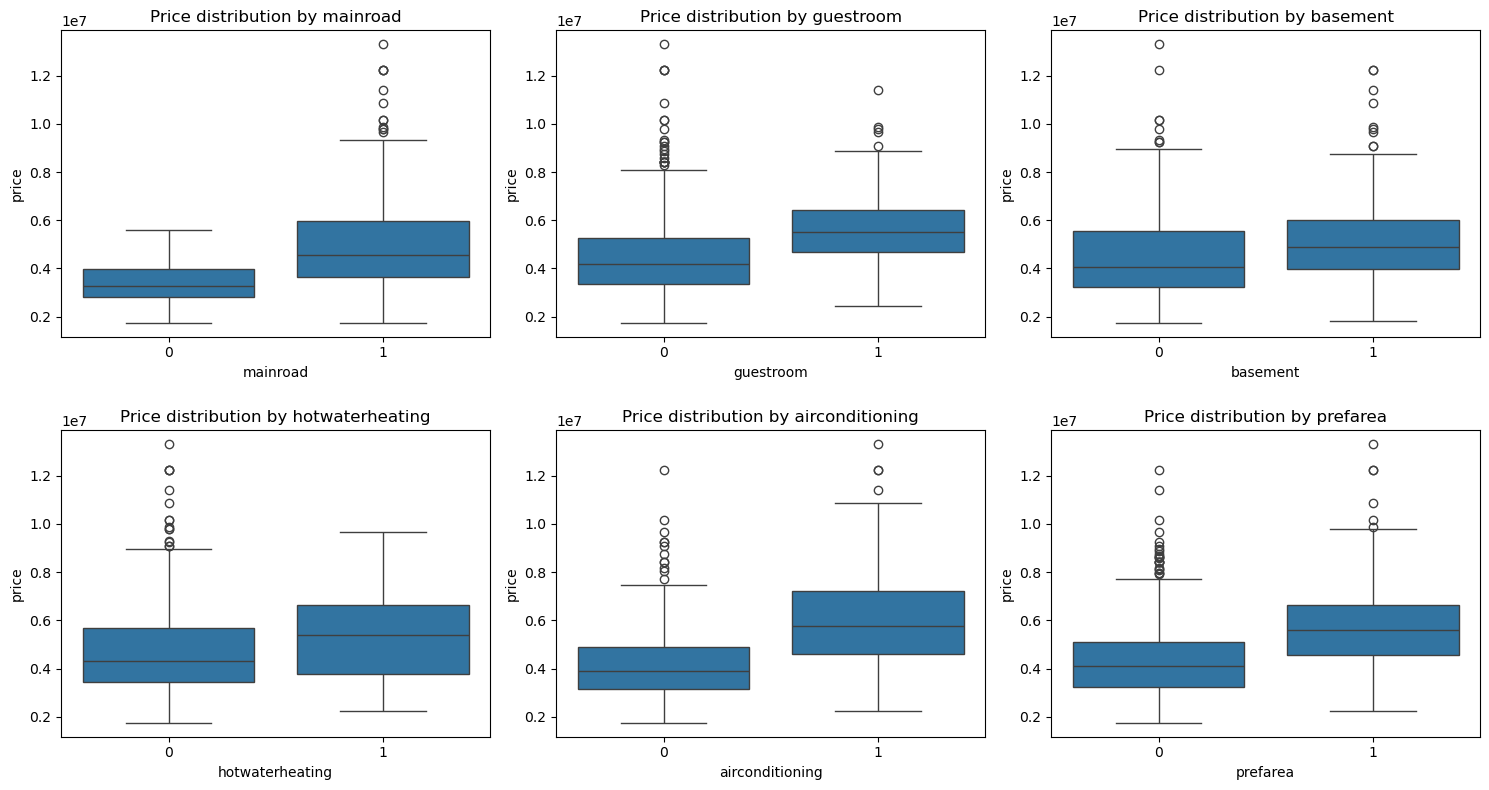

In [7]:
cat_features = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
plt.figure(figsize=(15,8))
for i, col in enumerate(cat_features):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col], y=df['price'])
    plt.title(f'Price distribution by {col}')
plt.tight_layout()
plt.show()

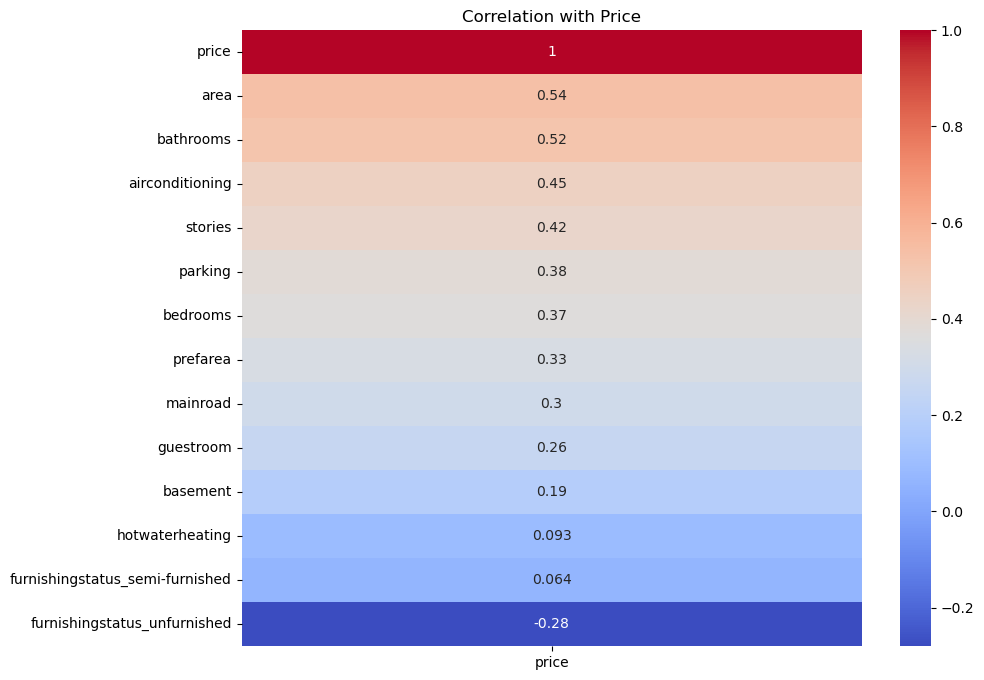

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr()[['price']].sort_values(by='price', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title('Correlation with Price')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [11]:
# Train a linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [12]:
# Generate predictions
y_pred = lr.predict(X_test)

In [13]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [14]:
print("Evaluation Metrics:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.2f}")


Evaluation Metrics:
MSE: 755664686763.83
RMSE: 869289.76
MAE: 706264.65
R^2: 0.73


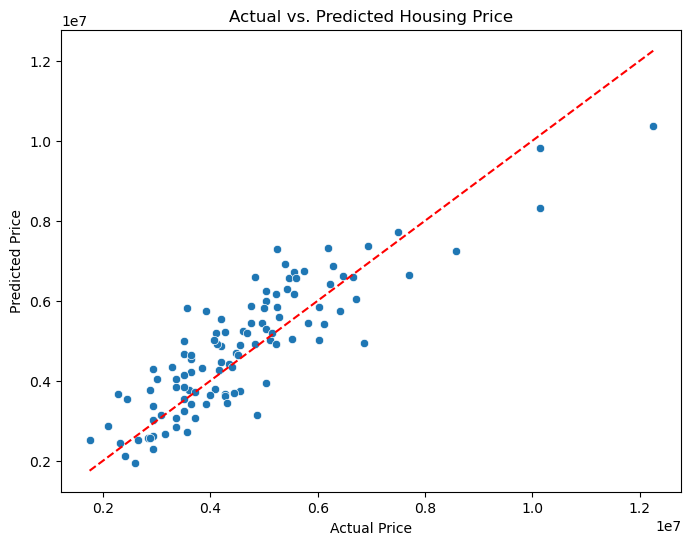

In [15]:

# 1. Scatter plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
# Plot a 45° line for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Housing Price")
plt.show()


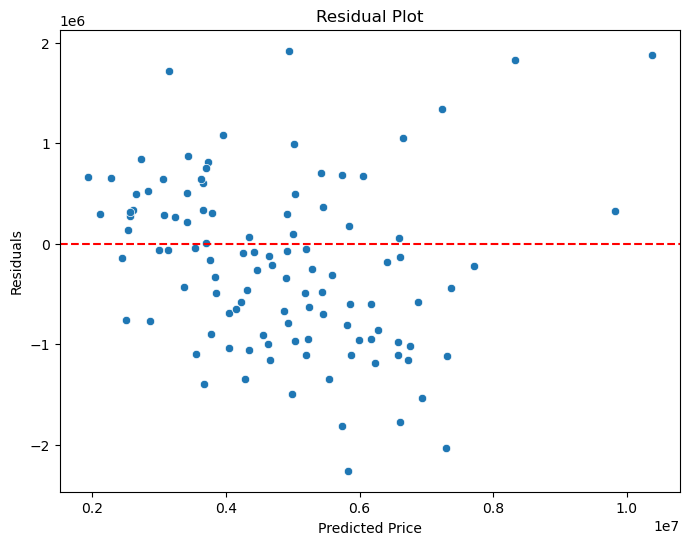

In [16]:
# 2. Residual Plot: To check if errors are randomly distributed
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

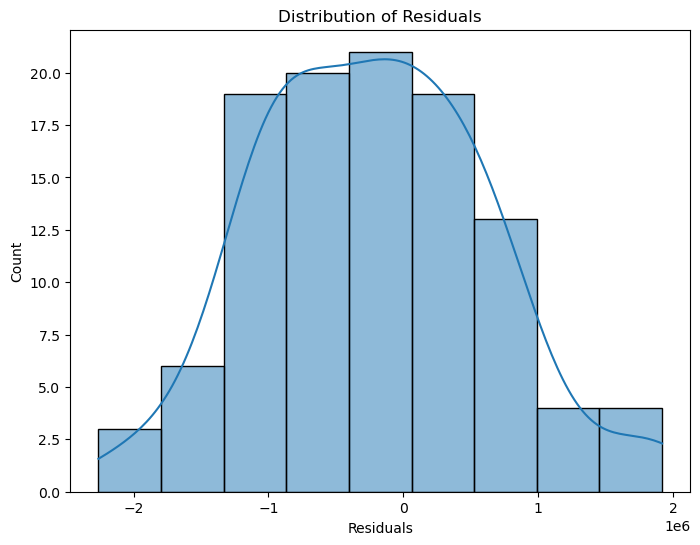

In [17]:
# 3. Distribution of Residuals: Check for normality
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

Scratch Implementation Evaluation Metrics:
MSE: 755669395235.71
RMSE: 869292.47
MAE: 706268.33
R^2: 0.73


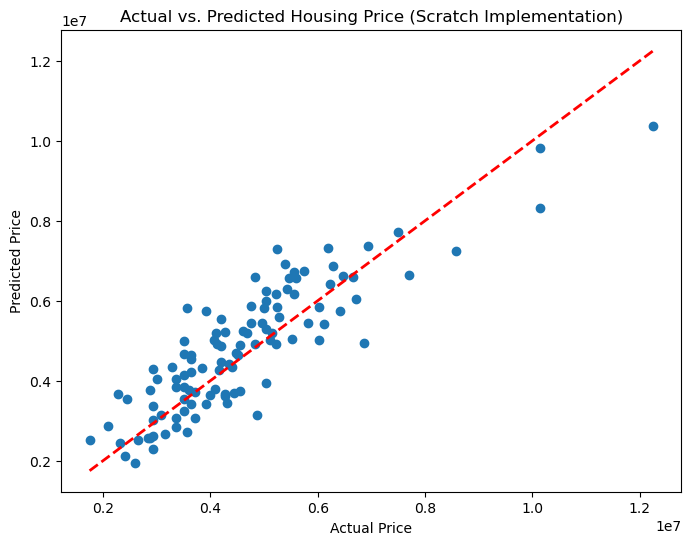

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Assuming you have already loaded and preprocessed your data as in your provided code:
# df = pd.read_csv("/home/ruthvik/Downloads/Housing.csv")
# ... (all preprocessing steps: mapping binary vars, one-hot encoding furnishingstatus, etc.)
# Also assume X_train, X_test, y_train, y_test are already obtained and that
# numerical features have been scaled using StandardScaler.

# For this scratch implementation we need to add an intercept term.
# We use np.c_ to concatenate a column of ones to both training and test sets.
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Convert y_train to a column vector for the math to work correctly.
y_train_vector = y_train.values.reshape(-1, 1)

# Set hyperparameters for gradient descent
learning_rate = 0.01   # You might need to tune this
n_iterations = 1000    # Number of iterations (epochs)
m = X_train_bias.shape[0]  # Number of training examples

# Initialize the parameter vector (θ) with random values.
theta = np.random.randn(X_train_bias.shape[1], 1)

# Gradient Descent Loop:
for iteration in range(n_iterations):
    # Compute predictions on training data
    predictions = X_train_bias.dot(theta)
    
    # Compute the error vector (difference between predictions and actual values)
    error = predictions - y_train_vector
    
    # Calculate the gradient of the cost function (mean squared error)
    gradients = (2/m) * X_train_bias.T.dot(error)
    
    # Update theta by taking a step in the direction opposite to the gradient
    theta = theta - learning_rate * gradients

# After training, use the learned parameters to predict on the test set.
y_pred_scratch = X_test_bias.dot(theta)

# Evaluate the model using common regression metrics:
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
mae_scratch = mean_absolute_error(y_test, y_pred_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)

print("Scratch Implementation Evaluation Metrics:")
print(f"MSE: {mse_scratch:.2f}")
print(f"RMSE: {rmse_scratch:.2f}")
print(f"MAE: {mae_scratch:.2f}")
print(f"R^2: {r2_scratch:.2f}")

# Optional: Visualize Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_scratch)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Housing Price (Scratch Implementation)")
plt.show()


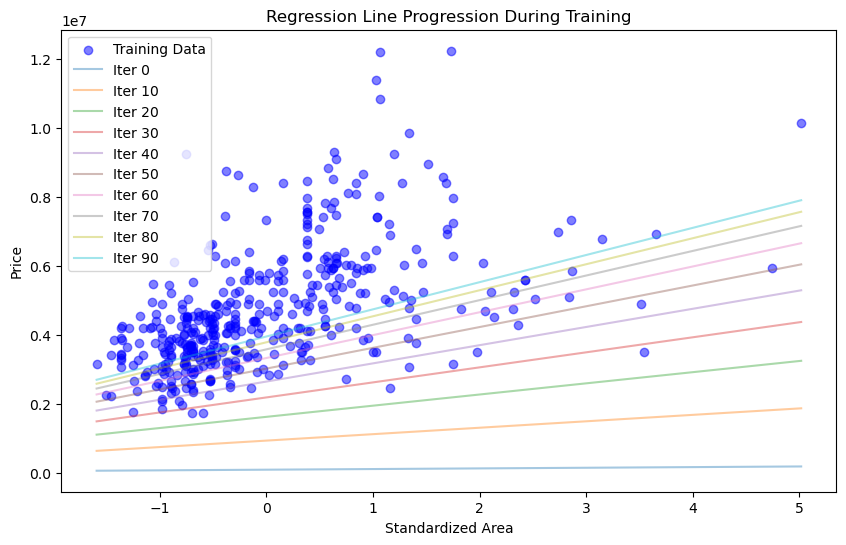

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("/home/ruthvik/Downloads/Housing.csv")

# Preprocess 'area' feature and target 'price'
X = df[['area']].values  # Using only 'area' as the feature
y = df['price'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add intercept term
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

y_train_vector = y_train.reshape(-1, 1)

# Hyperparameters
learning_rate = 0.01
n_iterations = 100  # Reduced for visualization
theta = np.random.randn(2, 1)  # Intercept and slope

# Setup plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train, color='blue', alpha=0.5, label='Training Data')
x_line = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 100).reshape(-1, 1)
x_line_bias = np.c_[np.ones((100, 1)), x_line]

for iteration in range(n_iterations):
    # Compute predictions and gradients
    predictions = X_train_bias.dot(theta)
    error = predictions - y_train_vector
    gradients = (2/len(X_train_bias)) * X_train_bias.T.dot(error)
    theta -= learning_rate * gradients
    
    # Plot every 10th iteration
    if iteration % 10 == 0:
        y_line = x_line_bias.dot(theta)
        plt.plot(x_line, y_line, alpha=0.4, label=f'Iter {iteration}')

plt.xlabel('Standardized Area')
plt.ylabel('Price')
plt.title('Regression Line Progression During Training')
plt.legend()
plt.show()